In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np
import torch 

In [10]:
data=pd.read_csv("ex2data1.txt",names=["exam1","exam2","admitted"])
data.head()

,exam1,exam2,admitted
0,34.623660,78.024693,0
1,30.286711,43.894998,0
2,35.847409,72.902198,0
3,60.182599,86.308552,1
4,79.032736,75.344376,1


In [11]:
data.describe()

,exam1,exam2,admitted
count,100.000000,100.000000,100.000000
mean,65.644274,66.221998,0.600000
std,19.458222,18.582783,0.492366
min,30.058822,30.603263,0.000000
25%,50.919511,48.179205,0.000000
50%,67.032988,67.682381,1.000000
75%,80.212529,79.360605,1.000000
max,99.827858,98.869436,1.000000


In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   exam1     100 non-null    float64
 1   exam2     100 non-null    float64
 2   admitted  100 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 2.5 KB


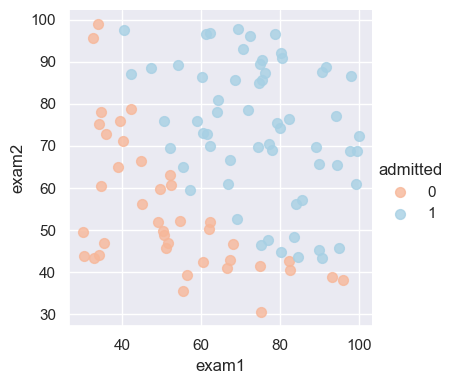

In [13]:
sns.set(context="notebook",style="darkgrid",palette=sns.color_palette("RdBu",2))
sns.lmplot(
    data=data,x="exam1",y="exam2",hue="admitted",# 当给出data的时候，不必进行像之前一样赋值，直接写出名字就可以了
    height=4,
    fit_reg=False, # 是否拟合直线
    scatter_kws={"s": 50}
    )

In [22]:
data_n=(data-data.mean())/data.std()
data_n["admitted"]=data["admitted"]
data_n.insert(0,"ones",1)

In [23]:
X_np=data_n.iloc[:,:-1].values
print(X_np)
Y_np=data_n.iloc[:,-1:].values
print(Y_np)

[[ 1.         -1.59421626  0.63514139]
 [ 1.         -1.81710142 -1.20148852]
 [ 1.         -1.53132516  0.35948329]
 [ 1.         -0.28068724  1.08092281]
 [ 1.          0.68806193  0.49090485]
 [ 1.         -1.05667395 -0.53305397]
 [ 1.         -0.23319754  1.62997263]
 [ 1.          0.48208266 -1.05839822]
 [ 1.          0.53727995  1.14076409]
 [ 1.          0.96558389 -1.22094762]
 [ 1.          1.55293123 -1.50659457]
 [ 1.          0.48151286 -1.91675998]
 [ 1.          0.85633616  0.5521221 ]
 [ 1.          0.19119499  1.69493955]
 [ 1.         -1.34164029  0.528167  ]
 [ 1.         -0.59991204  1.23691656]
 [ 1.          0.17606285 -0.72548489]
 [ 1.          0.11833462 -1.05169521]
 [ 1.          0.25784655  1.43709044]
 [ 1.          0.58250489 -1.00340376]
 [ 1.          0.08879298 -1.25834541]
 [ 1.          1.23508208 -0.02274321]
 [ 1.         -0.77650905 -0.93453099]
 [ 1.         -1.61536921 -1.18456258]
 [ 1.          0.63108629  0.14800592]
 [ 1.         -0.17335912

In [30]:
X_tensor=torch.tensor(X_np,dtype=torch.float32)
Y_tensor=torch.tensor(Y_np,dtype=torch.float32)
print(X_tensor)

tensor([[ 1.0000, -1.5942,  0.6351],
        [ 1.0000, -1.8171, -1.2015],
        [ 1.0000, -1.5313,  0.3595],
        [ 1.0000, -0.2807,  1.0809],
        [ 1.0000,  0.6881,  0.4909],
        [ 1.0000, -1.0567, -0.5331],
        [ 1.0000, -0.2332,  1.6300],
        [ 1.0000,  0.4821, -1.0584],
        [ 1.0000,  0.5373,  1.1408],
        [ 1.0000,  0.9656, -1.2209],
        [ 1.0000,  1.5529, -1.5066],
        [ 1.0000,  0.4815, -1.9168],
        [ 1.0000,  0.8563,  0.5521],
        [ 1.0000,  0.1912,  1.6949],
        [ 1.0000, -1.3416,  0.5282],
        [ 1.0000, -0.5999,  1.2369],
        [ 1.0000,  0.1761, -0.7255],
        [ 1.0000,  0.1183, -1.0517],
        [ 1.0000,  0.2578,  1.4371],
        [ 1.0000,  0.5825, -1.0034],
        [ 1.0000,  0.0888, -1.2583],
        [ 1.0000,  1.2351, -0.0227],
        [ 1.0000, -0.7765, -0.9345],
        [ 1.0000, -1.6154, -1.1846],
        [ 1.0000,  0.6311,  0.1480],
        [ 1.0000, -0.1734,  0.2009],
        [ 1.0000,  0.7475, -1.1516],
 

In [31]:
theta=torch.zeros((X_np.shape[1],1),requires_grad=True)

In [37]:
alpha=0.01
epochs=15000
w=len(X_tensor)

In [38]:
costs=[]
for i in range(epochs):
    z=X_tensor@theta
    y_hat=torch.sigmoid(z)
    loss=torch.nn.functional.binary_cross_entropy(y_hat,Y_tensor)
    costs.append(loss.item())

    loss.backward()
    
    with torch.no_grad():
        theta-=theta.grad*alpha
        theta.grad.zero_()
        
    if i % 100 == 0:
        print(f"Epoch {i}: Cost = {loss.item():.4f}")

print("\n训练完成！")
print(f"最终的 theta 为:\n{theta.detach().numpy()}")
    
    

Epoch 0: Cost = 0.2811
Epoch 100: Cost = 0.2767
Epoch 200: Cost = 0.2728
Epoch 300: Cost = 0.2692
Epoch 400: Cost = 0.2660
Epoch 500: Cost = 0.2630
Epoch 600: Cost = 0.2602
Epoch 700: Cost = 0.2577
Epoch 800: Cost = 0.2553
Epoch 900: Cost = 0.2532
Epoch 1000: Cost = 0.2511
Epoch 1100: Cost = 0.2492
Epoch 1200: Cost = 0.2475
Epoch 1300: Cost = 0.2458
Epoch 1400: Cost = 0.2442
Epoch 1500: Cost = 0.2427
Epoch 1600: Cost = 0.2414
Epoch 1700: Cost = 0.2400
Epoch 1800: Cost = 0.2388
Epoch 1900: Cost = 0.2376
Epoch 2000: Cost = 0.2365
Epoch 2100: Cost = 0.2354
Epoch 2200: Cost = 0.2344
Epoch 2300: Cost = 0.2335
Epoch 2400: Cost = 0.2325
Epoch 2500: Cost = 0.2317
Epoch 2600: Cost = 0.2308
Epoch 2700: Cost = 0.2300
Epoch 2800: Cost = 0.2293
Epoch 2900: Cost = 0.2285
Epoch 3000: Cost = 0.2278
Epoch 3100: Cost = 0.2272
Epoch 3200: Cost = 0.2265
Epoch 3300: Cost = 0.2259
Epoch 3400: Cost = 0.2253
Epoch 3500: Cost = 0.2247
Epoch 3600: Cost = 0.2242
Epoch 3700: Cost = 0.2236
Epoch 3800: Cost = 0.223

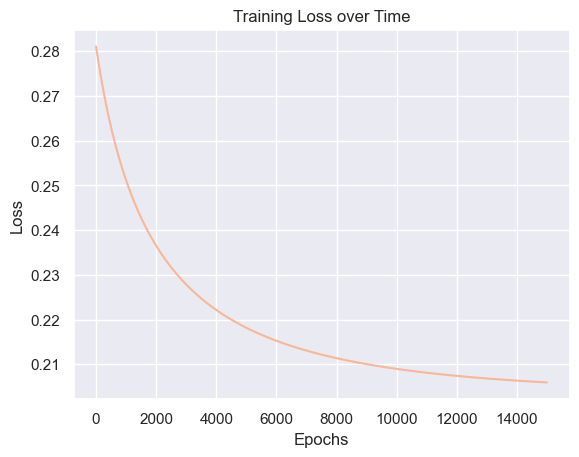

In [39]:
plt.plot(costs)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss over Time')
plt.show()

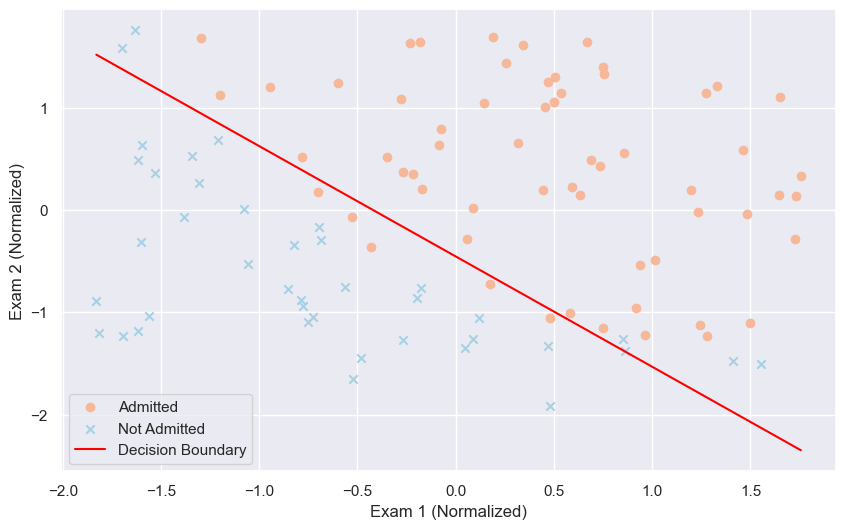

In [41]:
# 1. 把 theta 从 Tensor 变回 Numpy 数组方便画图
theta_final = theta.detach().numpy().flatten()

# 2. 准备横坐标（Exam 1 的范围）
x_boundary = np.linspace(X_tensor[:, 1].min(), X_tensor[:, 1].max(), 100)

# 3. 计算对应的纵坐标（Exam 2 的边界）
# 注意：theta_final[0] 是截距，[1] 是 exam1 的权重，[2] 是 exam2 的权重
y_boundary = -(theta_final[0] + theta_final[1] * x_boundary) / theta_final[2]
plt.figure(figsize=(10, 6))
plt.scatter(X_tensor[Y_tensor.flatten()==1, 1], X_tensor[Y_tensor.flatten()==1, 2], label='Admitted', marker='o')
plt.scatter(X_tensor[Y_tensor.flatten()==0, 1], X_tensor[Y_tensor.flatten()==0, 2], label='Not Admitted', marker='x')

plt.plot(x_boundary, y_boundary, color='red', label='Decision Boundary')
plt.xlabel('Exam 1 (Normalized)')
plt.ylabel('Exam 2 (Normalized)')
plt.legend()
plt.show()